# EDA for the raw dataset

In [45]:
import pandas as pd
import matplotlib

DATASET = '../data/raw/Social_media_impact_on_life.csv'

social_media = pd.read_csv(DATASET)

## First interaction with the data

### Dataset size 

In [27]:
social_media.shape

(4500, 16)

### Types dataset

In [28]:
social_media.info()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   str    
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   str    
 3   Academic_Level               4500 non-null   str    
 4   Primary_Platform             4500 non-null   str    
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   str    
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   str    
 12  Perceived_Stress_Score       4500 non-null   float64
 13  Mental_Health_Index          

### Review numeric variables

I think its good, I'm worried about Academic Performance, because the count is less than 4500 so can be has null values

In [29]:
social_media.describe()

,Age,Daily_Usage_Hours,Weekend_Extra_Hours,Sleep_Duration_Hours,Sleep_Quality_Score,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4415.000000
mean,18.703333,5.295933,1.796844,6.701333,2.472000,13.506889,79.873111,3.429282
std,1.981182,2.604497,0.699245,1.189998,1.030484,7.036797,12.876044,0.392662
min,15.000000,0.900000,0.000000,3.000000,1.000000,0.000000,32.000000,1.900000
25%,17.000000,3.400000,1.300000,6.000000,2.000000,9.000000,72.000000,3.200000
50%,19.000000,4.700000,1.800000,6.800000,3.000000,13.000000,82.000000,3.460000
75%,20.000000,6.600000,2.300000,7.500000,3.000000,18.000000,89.000000,3.720000
max,26.000000,14.000000,4.500000,10.500000,5.000000,40.000000,98.000000,4.000000


### Review categoric variables

I think in this case we don't have null values in this variables

In [30]:
cols = ["Gender", "Academic_Level", "Primary_Platform", "Device_Type", "Late_Night_Usage", "Overall_Impact"]

for col in cols:
    counts = social_media[col].value_counts()
    print(f"=== {col} ===")
    print(counts)
    print(f"Total: {counts.sum()}")
    print("-" * 30)

=== Gender ===
Gender
Female               2234
Male                 2051
Non-Binary            122
Prefer not to say      93
Name: count, dtype: int64
Total: 4500
------------------------------
=== Academic_Level ===
Academic_Level
Undergraduate    2777
High School      1477
Postgraduate      246
Name: count, dtype: int64
Total: 4500
------------------------------
=== Primary_Platform ===
Primary_Platform
Instagram      1453
TikTok         1226
YouTube         818
Snapchat        472
Reddit          229
X (Twitter)     206
LinkedIn         96
Name: count, dtype: int64
Total: 4500
------------------------------
=== Device_Type ===
Device_Type
Smartphone    3775
Laptop/PC      596
Tablet         129
Name: count, dtype: int64
Total: 4500
------------------------------
=== Late_Night_Usage ===
Late_Night_Usage
True     2644
False    1856
Name: count, dtype: int64
Total: 4500
------------------------------
=== Overall_Impact ===
Overall_Impact
Beneficial    3681
Neutral        654
Negative

### Null values

As I say we have null values in a important variable, but I think I can use this with the mean of the others values because its just 85 and the total should be 4500 for GPA or we can delete that null values for GPA because its my objective variable
and for Perceived_Stress_Score we can do the median thing, replace the null values with the median 

In [31]:
social_media.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Primary_Platform                0
Daily_Usage_Hours               0
Weekend_Extra_Hours             0
Device_Type                     0
Sleep_Duration_Hours            0
Sleep_Quality_Score             0
Late_Night_Usage                0
Social_Comparison_Frequency     0
Perceived_Stress_Score          0
Mental_Health_Index             0
Academic_Performance_GPA       85
Overall_Impact                  0
dtype: int64

In [32]:
social_media.isnull().mean() * 100

Student_ID                     0.000000
Age                            0.000000
Gender                         0.000000
Academic_Level                 0.000000
Primary_Platform               0.000000
Daily_Usage_Hours              0.000000
Weekend_Extra_Hours            0.000000
Device_Type                    0.000000
Sleep_Duration_Hours           0.000000
Sleep_Quality_Score            0.000000
Late_Night_Usage               0.000000
Social_Comparison_Frequency    0.000000
Perceived_Stress_Score         0.000000
Mental_Health_Index            0.000000
Academic_Performance_GPA       1.888889
Overall_Impact                 0.000000
dtype: float64

#### Academic_Performance_GPA

We need to delete the null rows

In [33]:
social_media_ml = social_media.dropna(subset=["Academic_Performance_GPA"])

#### Perceived_Stress_Score

In [34]:
social_media["Perceived_Stress_Score"].describe()

count    4500.000000
mean       13.506889
std         7.036797
min         0.000000
25%         9.000000
50%        13.000000
75%        18.000000
max        40.000000
Name: Perceived_Stress_Score, dtype: float64

A easy option is replace the data with the median

In [35]:
social_media["Perceived_Stress_Score"] = social_media["Perceived_Stress_Score"].fillna(
    social_media["Perceived_Stress_Score"].median()
)
social_media_ml = social_media_ml.dropna(subset=["Academic_Performance_GPA"]).copy()

### Duplicates

In [36]:
social_media.duplicated().sum()

np.int64(0)

### Dataset clean for ML, but we continue with EDA to discard variables and verify correlations

In [37]:
social_media_ml.shape

(4415, 16)

### Create the dataset

In [40]:
social_media_ml.to_csv("../data/processed/social_media_ml.csv", index=False)

### First view in the data

In [38]:
social_media.head()

,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


### With this data I'm curious if the social media use has an impact in the GPA

So I think my main variables are going to be:

1. Daily_Usage_Hours
2. Weekend_Extra_Hours
3. Late_Night_Usage
4. Sleep_Quality_Score
5. Social_Comparison_Frequency
6. Perceived_Stress_Score
7. Mental_Health_Index

And context variables are going to be:

1. Age
2. Gender
3. Academic_Level
4. Primary_Platform
5. Device_type

Because I think the main factor is the hours and frequency

In [42]:
social_media_ml["Academic_Performance_GPA"].describe()

count    4415.000000
mean        3.429282
std         0.392662
min         1.900000
25%         3.200000
50%         3.460000
75%         3.720000
max         4.000000
Name: Academic_Performance_GPA, dtype: float64

### Distribution of the objetive variable

The GPA ranges from 1.9 to 4.0, with a mean of 3.43 and a median of 3.46. Most students have a GPA between 3.20 and 3.72.

<Axes: >

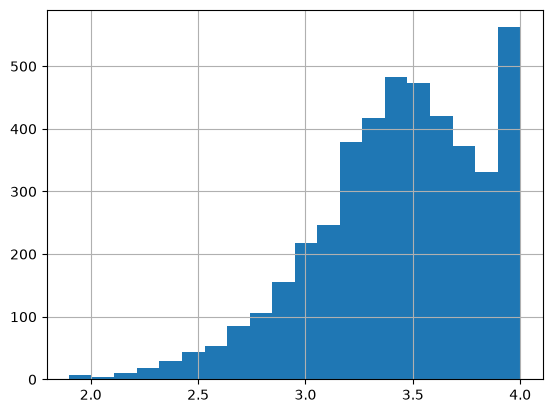

In [46]:
social_media_ml["Academic_Performance_GPA"].hist(bins=20)

<Axes: xlabel='Daily_Usage_Hours', ylabel='Academic_Performance_GPA'>

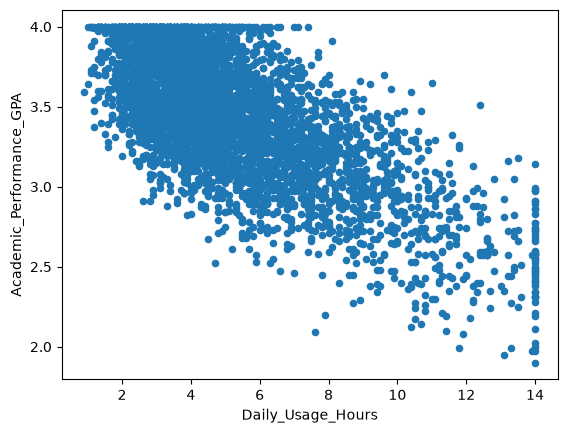

In [48]:
social_media_ml.plot.scatter(
    x="Daily_Usage_Hours",
    y="Academic_Performance_GPA"
)

There appears to be a negative association between daily social media usage and academic performance.

In [50]:
social_media_ml["Daily_Usage_Hours"].value_counts().sort_index()

Daily_Usage_Hours
0.9      1
1.0      2
1.1      6
1.2      8
1.3     11
        ..
13.4     6
13.5     4
13.6     2
13.9     2
14.0    54
Name: count, Length: 129, dtype: int64

In [51]:
social_media_ml["Daily_Usage_Hours"].describe()

count    4415.000000
mean        5.301133
std         2.608000
min         0.900000
25%         3.400000
50%         4.700000
75%         6.600000
max        14.000000
Name: Daily_Usage_Hours, dtype: float64

We have both numerical and categorical variables, and the relationships between social media usage, sleep, stress, and academic performance may not be purely linear. Random Forest can capture non-linear relationships and interactions between features without requiring us to specify those relationships beforehand.